# 06. Baseline Model — Stage 0

This notebook establishes the first predictive baseline for the market-volatility
problem developed in Stage 0.

The feature set was constructed in `05_feature_engineering_s0.ipynb` using
statistical features motivated by `03_eda.ipynb` together with topological
features derived in `04_tda.ipynb`.

The prediction task is binary classification. For each date \(t\), the model
predicts whether the future five-day realized volatility is sufficiently higher
than the current 20-day volatility.

The objective of this notebook is to establish a reproducible baseline against
which the subsequent modeling stages can be compared.

Because the data are a time series, observations are divided chronologically
into training, validation, and test sets. No random shuffling is used.

The same chronological evaluation framework will be used for the subsequent
Stage-0 models and will serve as the reference framework for the later
1-dimensional CNN and data-augmentation experiments.

## 1. Project Setup

### 1.1: Define Project Path

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

STAGE0_DATA_FILE = (
    PROCESSED_DATA_DIR / "spy_stage0_features.csv"
)

### 1.2: Import Libraries

In [29]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

## 2. Load the Stage-0 Dataset

The Stage-0 dataset was constructed in
`05_feature_engineering_s0.ipynb`.

It contains the statistical and topological features together with the binary
prediction target. We load the saved dataset here so that the modeling
experiments operate on exactly the feature set defined in the feature
engineering stage.

In [4]:
# Load the Stage-0 dataset.

stage0_data = pd.read_csv(
    STAGE0_DATA_FILE,
    index_col=0,
    parse_dates=True
)

stage0_data.head()

,log_return,abs_return,squared_return,vol_5d,vol_10d,vol_20d,vol_60d,vol_ratio_5_20,vol_ratio_20_60,abs_return_lag_1,...,h0_mean_persistence,h0_max_persistence,h1_total_persistence,h1_mean_persistence,h1_max_persistence,h1_n_features,h1_l1_norm,h1_l2_norm,h1_sup_norm,target
date,,,,,,,,,,,,,,,,,,,,,
2010-03-31,-0.003413,0.003413,0.000012,0.003322,0.004271,0.005152,0.008848,0.644720,0.582289,0.000681,...,0.003322,0.007881,0.000868,0.000868,0.000868,1,1.883799e-07,0.000007,0.000434,0
2010-04-01,0.006815,0.006815,0.000046,0.004449,0.004781,0.005330,0.008885,0.834670,0.599885,0.003413,...,0.002969,0.007881,0.000868,0.000868,0.000868,1,1.883799e-07,0.000007,0.000434,0
2010-04-05,0.008116,0.008116,0.000066,0.005735,0.005184,0.004651,0.008946,1.233187,0.519877,0.006815,...,0.002615,0.004491,0.000868,0.000868,0.000868,1,1.883799e-07,0.000007,0.000434,0
2010-04-06,0.002355,0.002355,0.000006,0.005098,0.004958,0.004680,0.008934,1.089330,0.523846,0.008116,...,0.002702,0.004491,0.000688,0.000344,0.000555,2,8.148190e-08,0.000004,0.000278,0
2010-04-07,-0.005729,0.005729,0.000033,0.005698,0.004791,0.004838,0.008955,1.177664,0.540292,0.002355,...,0.002828,0.005156,0.001775,0.000444,0.001358,4,4.757887e-07,0.000014,0.000679,1


verify the dataset:

In [5]:
print("Shape:", stage0_data.shape)
print("First date:", stage0_data.index.min())
print("Last date:", stage0_data.index.max())
print("Missing values:", stage0_data.isna().sum().sum())

Shape: (4131, 28)
First date: 2010-03-31 00:00:00
Last date: 2026-09-01 00:00:00
Missing values: 0


Inspect the target:

In [6]:
print("Target distribution:")
print(stage0_data["target"].value_counts())

print("\nTarget proportions:")
print(stage0_data["target"].value_counts(normalize=True))

Target distribution:
target
0    3118
1    1013
Name: count, dtype: int64

Target proportions:
target
0    0.754781
1    0.245219
Name: proportion, dtype: float64


## 3. Chronological Train, Validation, and Test Split

Because the data are financial time series, observations must be evaluated in
chronological order. Randomly shuffling the observations would allow
information from later market conditions to influence the training process and
would not reflect the way the model would be used in practice.

For Stage 0, we therefore divide the dataset into three contiguous calendar
periods:

| Set | Period | Purpose |
| --- | --- | --- |
| Training | 2010--2020 | Model fitting |
| Validation | 2021--2022 | Model and hyperparameter selection |
| Test | 2023--2026 | Final out-of-sample evaluation |

This choice provides a relatively long training period containing several
different market and volatility regimes. The validation period consists of
more recent observations and is used during model development, while the
test period contains the latest observations and is kept untouched until
final evaluation.

Thus,

$$
\text{Train} < \text{Validation} < \text{Test}.
$$

The same chronological evaluation framework will be used when comparing the
Stage-0 models. In particular, the test set will not be used for feature
selection, hyperparameter tuning, or model development.

This separation is especially important because later stages of the project
will investigate increasingly sophisticated approaches, including
one-dimensional CNNs and data augmentation based on symmetry, topology, and
the statistical distribution of the data.

For the later data-augmentation experiments, augmentation will initially be
applied only to the training data. The validation and test sets will remain
unaltered so that they continue to represent genuinely unseen observations.

For Stage 0, we use this fixed chronological split as a simple and
reproducible evaluation protocol. More sophisticated approaches, such as
walk-forward validation across different market regimes, can be investigated
in later stages.

### 3.1: Inspect the Proposed Split

Before creating the train, validation, and test sets, we inspect the number of
observations and target-class proportions in each chronological period.

This provides a basic check that the proposed split contains sufficient data
for model training and evaluation and that the target distribution does not
change drastically between the three periods.

In [7]:
TRAIN_END = "2020-12-31"
VALIDATION_END = "2022-12-31"

train_mask = stage0_data.index <= TRAIN_END
validation_mask = (
    (stage0_data.index > TRAIN_END)
    & (stage0_data.index <= VALIDATION_END)
)
test_mask = stage0_data.index > VALIDATION_END

train_preview = stage0_data.loc[train_mask]
validation_preview = stage0_data.loc[validation_mask]
test_preview = stage0_data.loc[test_mask]

In [8]:
split_summary = pd.DataFrame({
    "Set": ["Train", "Validation", "Test"],
    "Start": [
        train_preview.index.min(),
        validation_preview.index.min(),
        test_preview.index.min(),
    ],
    "End": [
        train_preview.index.max(),
        validation_preview.index.max(),
        test_preview.index.max(),
    ],
    "Observations": [
        len(train_preview),
        len(validation_preview),
        len(test_preview),
    ],
    "Class 0": [
        (train_preview["target"] == 0).sum(),
        (validation_preview["target"] == 0).sum(),
        (test_preview["target"] == 0).sum(),
    ],
    "Class 1": [
        (train_preview["target"] == 1).sum(),
        (validation_preview["target"] == 1).sum(),
        (test_preview["target"] == 1).sum(),
    ],
})

split_summary["Class 1 (%)"] = (
    100 * split_summary["Class 1"]
    / split_summary["Observations"]
)

split_summary

,Set,Start,End,Observations,Class 0,Class 1,Class 1 (%)
0,Train,2010-03-31,2020-12-31,2709,2012,697,25.729051
1,Validation,2021-01-04,2022-12-30,503,377,126,25.049702
2,Test,2023-01-03,2026-09-01,919,729,190,20.674646


### 3.2 Create the Chronological Split

We now create the training, validation, and test datasets using the calendar
boundaries defined above.

In [9]:
train_data = stage0_data.loc[train_mask].copy()
validation_data = stage0_data.loc[validation_mask].copy()
test_data = stage0_data.loc[test_mask].copy()

In [10]:
# verify
print("Train:", train_data.shape)
print("Validation:", validation_data.shape)
print("Test:", test_data.shape)

Train: (2709, 28)
Validation: (503, 28)
Test: (919, 28)


### 3.3 Separate Features and Target

The Stage-0 dataset contains 27 predictive features and one binary target
column.

We now separate the feature matrix \(X\) from the target vector \(y\):

$$
X = \text{feature variables},
\qquad
y = \text{target}.
$$

The same feature columns are used for all three datasets. The target is kept
separate so that the resulting objects can be passed directly to the
classification models.

In [11]:
FEATURE_COLUMNS = [
    column for column in stage0_data.columns
    if column != "target"
]

X_train = train_data[FEATURE_COLUMNS]
y_train = train_data["target"]

X_validation = validation_data[FEATURE_COLUMNS]
y_validation = validation_data["target"]

X_test = test_data[FEATURE_COLUMNS]
y_test = test_data["target"]

In [12]:
# verify the dimensions
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (2709, 27)
y_train: (2709,)
X_validation: (503, 27)
y_validation: (503,)
X_test: (919, 27)
y_test: (919,)


### 4. Baseline Model

We begin with logistic regression as a simple classification baseline.

Logistic regression models the probability of the positive class as

$$
P(y=1\mid X)
=
\sigma(\beta_0 + \beta^T X),
$$

where

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

is the logistic function.

The purpose of this model is not to obtain the most powerful predictor.
Instead, it provides a simple reference point against which the more
flexible models introduced later can be compared.

Because logistic regression is sensitive to the scale of the input features,
the features will be standardized using statistics computed from the training
set only.

### 4.1: Feature Standardization

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_validation_scaled = scaler.transform(X_validation)

X_test_scaled = scaler.transform(X_test)

In [18]:
# verify
print("Training mean:", X_train_scaled.mean(axis=0).mean())
print("Training standard deviation:",
      X_train_scaled.std(axis=0).mean())

Training mean: 2.4504655960992207e-17
Training standard deviation: 1.0


### 4.2 Logistic Regression

We now fit the logistic-regression model using the standardized training
features.

The model is trained only on the training set. The validation set will be used
to evaluate the model during model development, while the test set remains
untouched until the final evaluation stage.

In [19]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [20]:
# verify
print("Model fitted successfully.")

Model fitted successfully.


### 4.3 Validation Predictions

We now use the fitted logistic-regression model to generate predictions on the
validation set.

Two outputs are useful:

1. **Class predictions**, which assign each observation to class 0 or 1.
2. **Predicted probabilities**, which give the model's estimated probability
   that an observation belongs to class 1.

The class prediction is obtained using the model's default decision threshold,
while the predicted probability will allow us to evaluate metrics such as
ROC-AUC without fixing a particular classification threshold.

In [21]:
y_validation_pred = baseline_model.predict(
    X_validation_scaled
)

y_validation_proba = baseline_model.predict_proba(
    X_validation_scaled
)[:, 1]

inspect the first few predictions:

In [22]:
validation_predictions = pd.DataFrame({
    "actual": y_validation.to_numpy(),
    "predicted": y_validation_pred,
    "probability_class_1": y_validation_proba
}, index=y_validation.index)

validation_predictions.head(10)

,actual,predicted,probability_class_1
date,,,
2021-01-04,1,1,0.591917
2021-01-05,1,1,0.500357
2021-01-06,1,0,0.463659
2021-01-07,0,0,0.410355
2021-01-08,0,0,0.482527
2021-01-11,0,0,0.452402
2021-01-12,0,0,0.351771
2021-01-13,0,0,0.264591
2021-01-14,1,0,0.351941


A couple of things are worth noticing in the output:

- On 2021-01-04, the model predicted class 1 with probability 0.591917, so the class prediction is 1.
- On 2021-01-06, the probability is 0.463659, so the model predicts class 0, even though the actual class is 1.
- On 2021-01-05, the probability is 0.500357, just above 0.5, so it predicts class 1.
- The probability column gives us more information than the binary prediction alone. For example, 0.501 and 0.99 are both class-1 predictions, but the model's confidence is very different.
  
So the prediction step is working as intended.

### 4.4 Validation Performance

We evaluate the baseline model on the validation set using several
classification metrics.

Accuracy measures the fraction of observations classified correctly. Precision
measures the fraction of predicted positive cases that are actually positive,
while recall measures the fraction of actual positive cases that the model
identifies. The F1 score combines precision and recall through their harmonic
mean.

We also report the area under the receiver operating characteristic curve
(ROC-AUC). Unlike accuracy, ROC-AUC uses the predicted probabilities and
measures how well the model distinguishes between the two classes across
different classification thresholds.

In [23]:
# import the mterics 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

In [24]:
# next, cacluate them 
validation_accuracy = accuracy_score(
    y_validation,
    y_validation_pred
)

validation_precision = precision_score(
    y_validation,
    y_validation_pred
)

validation_recall = recall_score(
    y_validation,
    y_validation_pred
)

validation_f1 = f1_score(
    y_validation,
    y_validation_pred
)

validation_roc_auc = roc_auc_score(
    y_validation,
    y_validation_proba
)

In [25]:
# finally, display them together 
validation_metrics = pd.Series({
    "Accuracy": validation_accuracy,
    "Precision": validation_precision,
    "Recall": validation_recall,
    "F1": validation_f1,
    "ROC-AUC": validation_roc_auc,
})

validation_metrics

Accuracy     0.769384
Precision    0.708333
Recall       0.134921
F1           0.226667
ROC-AUC      0.694392
dtype: float64

These results are quite informative. The baseline is behaving almost exactly as we'd want a diagnostic baseline to reveal the difficulty of the problem.

The accuracy of 76.9% is not very informative by itself. Remember that about 75% of the validation observations are class 0. So a model that almost always predicts class 0 could already achieve roughly 75% accuracy.

The more revealing number is recall = 0.135.
That means the model is identifying only about 13.5% of the actual Class-1 events at the default 0.5 probability threshold.

At the same time, its precision is 0.708: when it does predict Class 1, it is correct fairly often.
So the model is being conservative about predicting Class 1.

The interesting result is the ROC-AUC = 0.694. This tells us that the model's probability scores contain substantially more information than the 0/1 predictions at the fixed 0.5 threshold. In other words, the logistic model may be distinguishing the two classes to some extent, even though its default threshold produces poor recall.

That distinction is important for our project because the question isn't necessarily:
"Can logistic regression classify the observations correctly at a threshold of 0.5?"

We're ultimately interested in whether the features contain information about the future volatility event.

### 4.5 Confusion Matrix

The confusion matrix shows the number of observations assigned to each
combination of actual and predicted class.

It allows us to examine the types of classification errors made by the
baseline model, particularly the number of false negatives associated with
the relatively low validation recall.

In [26]:
from sklearn.metrics import confusion_matrix

validation_confusion_matrix = confusion_matrix(
    y_validation,
    y_validation_pred
)

validation_confusion_matrix

array([[370,   7],
       [109,  17]])

This explains the earlier metrics very clearly.

There are 126 actual Class-1 observations:
$$
109+17=126.
$$
The model identifies only 17 of them:
$$
\text{Recall}=\frac{17}{109+17}
=\frac{17}{126}
\approx 0.135.
$$
So the low recall isn't a calculation artifact—the model really is missing 109 of the 126 positive events at the default 0.5 threshold.
On the other hand, it makes only 7 false-positive predictions. Thus, when it does predict Class 1, it is usually correct:
$$
\text{Precision}
=
\frac{17}{17+7}
\approx0.708.
$$
This is a useful baseline result.

**One particularly interesting point:**

The ROC-AUC of 0.694 suggests that the model's probability ranking has useful information even though the default 0.5 threshold gives poor recall.
That gives us a natural next question:
What happens if we vary the classification threshold?

But we will not change the model's threshold yet. For a baseline, the default 0.5 result is valuable. Instead, let's first visualize the ROC curve, which will connect the probability-based ROC-AUC to the actual predictions.

### 4.6 Receiver Operating Characteristic Curve

The receiver operating characteristic (ROC) curve shows how the model's
true-positive rate changes as the classification threshold is varied.

The curve is constructed from the predicted probabilities rather than the
default class predictions. The area under this curve is the ROC-AUC reported
above.

A model with no discriminative ability has an ROC-AUC of approximately 0.5,
while larger values indicate better separation between the two classes.

In [27]:
from sklearn.metrics import roc_curve, auc

In [28]:
# compute the curve 
fpr, tpr, thresholds = roc_curve(
    y_validation,
    y_validation_proba
)

roc_auc = auc(fpr, tpr)

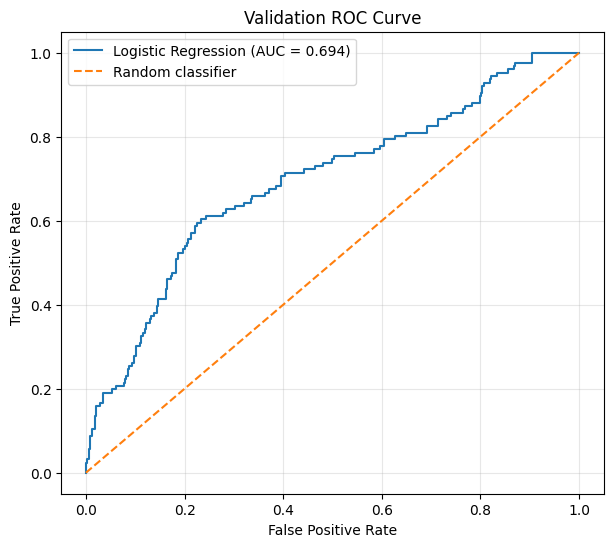

In [30]:
# plot it
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

A few observations:

- The curve is clearly above the random-classifier diagonal over much of the range.
- Thus, the logistic regression is learning some discriminative information from the 27 features.
- However, the separation is not extremely strong; the AUC of 0.694 indicates moderate discrimination rather than near-perfect classification.
- This also explains the earlier result: the model can rank observations reasonably, while the default 0.5 threshold produces very few positive predictions.
  
Let's add a precision-recall curve next. It is particularly relevant here because Class 1 is the minority class (~25% in validation), and the confusion matrix showed that the model has very low recall at the default threshold.

### 4.7 Precision-Recall Curve

Because Class 1 is less frequent than Class 0, we also examine the
precision-recall curve.

The precision-recall curve shows the trade-off between precision and recall
as the classification threshold is varied. This provides a complementary view
of model performance to the ROC curve, particularly for the positive class.

As with the ROC curve, the curve is constructed using the predicted
probabilities rather than the default class predictions.

In [31]:
from sklearn.metrics import precision_recall_curve, average_precision_score

In [32]:
# compute
precision, recall, pr_thresholds = precision_recall_curve(
    y_validation,
    y_validation_proba
)

average_precision = average_precision_score(
    y_validation,
    y_validation_proba
)

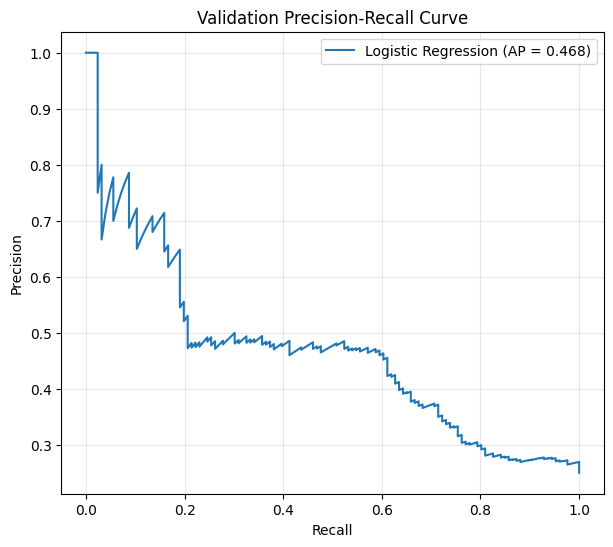

In [33]:
# plot 
plt.figure(figsize=(7, 6))

plt.plot(
    recall,
    precision,
    label=f"Logistic Regression (AP = {average_precision:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Validation Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 4.8 Validation Results Summary

The following table summarizes the performance of the logistic-regression
baseline on the validation set.

These results are used to characterize the baseline model before final
evaluation on the test set. No threshold tuning is performed at this stage.

In [34]:
validation_results = pd.Series({
    "Accuracy": validation_accuracy,
    "Precision": validation_precision,
    "Recall": validation_recall,
    "F1": validation_f1,
    "ROC-AUC": validation_roc_auc,
    "Average Precision": average_precision,
})

validation_results

Accuracy             0.769384
Precision            0.708333
Recall               0.134921
F1                   0.226667
ROC-AUC              0.694392
Average Precision    0.468380
dtype: float64

## 5. Final Test Evaluation

The test set contains observations from January 2023 onward and was not used
during feature construction, model fitting, or validation analysis.

We now evaluate the already-fitted baseline model on this held-out period.

No model or threshold adjustments are made based on the test results. The test
set therefore provides the final out-of-sample assessment of the baseline
under the Stage-0 evaluation protocol.

In [35]:
y_test_pred = baseline_model.predict(
    X_test_scaled
)

y_test_proba = baseline_model.predict_proba(
    X_test_scaled
)[:, 1]

In [36]:
test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred
)

test_recall = recall_score(
    y_test,
    y_test_pred
)

test_f1 = f1_score(
    y_test,
    y_test_pred
)

test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_average_precision = average_precision_score(
    y_test,
    y_test_proba
)

In [37]:
test_results = pd.Series({
    "Accuracy": test_accuracy,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1": test_f1,
    "ROC-AUC": test_roc_auc,
    "Average Precision": test_average_precision,
})

test_results

Accuracy             0.799782
Precision            0.565217
Recall               0.136842
F1                   0.220339
ROC-AUC              0.735268
Average Precision    0.409892
dtype: float64

A few things stand out.

1. Accuracy increases, from 76.9% to 80.0%. But the test-set Class-1 prevalence is only about 20.7%, so the majority-class accuracy is already about 79.3%. Thus, the 80.0% accuracy should not be interpreted as strong classification performance.
2. Recall is essentially unchanged:
   $$
   0.135\rightarrow0.137.
   $$
   So at the default 0.5 threshold, the model continues to identify only about 14% of the positive events.
3. Precision decreases from 0.708 to 0.565. Thus, the positive predictions are less reliable on the test period.
4. ROC-AUC actually increases:
   $$
   0.694\rightarrow0.735.
   $$
   This is interesting: the model's probability ranking appears to discriminate the two classes somewhat better in the test period, despite its poor performance at the fixed 0.5 threshold.
5. Average Precision decreases from 0.468 to 0.409. Since the positive-class prevalence also falls substantially in the test period, AP should be interpreted alongside that prevalence rather than in isolation.
So I would summarize the baseline at this point as:
The logistic-regression baseline contains some predictive information, particularly in its probability scores, but its default 0.5 classification threshold has very low recall for the positive volatility-event class.

That's actually a useful result for the project. It gives us a meaningful baseline to beat rather than simply producing an apparently high accuracy number.
Next: test confusion matrix
I suggest we do the same diagnostic for the test set before moving on:

### 5.1 Test Confusion Matrix

We examine the confusion matrix on the held-out test set to understand the
classification errors made by the baseline model.

In [38]:
test_confusion_matrix = confusion_matrix(
    y_test,
    y_test_pred
)

test_confusion_matrix

array([[709,  20],
       [164,  26]])

There are $190$ actual Class-1 observations:
$$
164+26=190,
$$
and the model identifies only 26:
$$
\frac{26}{190}\approx 0.137,
$$
which is exactly the recall of about 0.137 we obtained.
So the test confusion matrix confirms the same qualitative behavior we saw on validation: the default 0.5 threshold produces very few Class-1 predictions.
We will now make the final comparison table between validation and test.

### 5.2 Validation and Test Performance

We compare the validation and test performance of the logistic-regression
baseline using the same evaluation metrics.

The validation results characterize the model during development, while the
test results provide the final out-of-sample evaluation on the held-out
2023--2026 period.

In [39]:
comparison = pd.DataFrame({
    "Validation": validation_results,
    "Test": test_results,
})

comparison

,Validation,Test
Accuracy,0.769384,0.799782
Precision,0.708333,0.565217
Recall,0.134921,0.136842
F1,0.226667,0.220339
ROC-AUC,0.694392,0.735268
Average Precision,0.468380,0.409892


## 6. Baseline Conclusions

The logistic-regression model provides a simple reference point for the
Stage-0 prediction problem.

The model achieves moderate discrimination according to ROC-AUC, with a
validation ROC-AUC of approximately 0.69 and a test ROC-AUC of approximately
0.74. Its average precision is approximately 0.47 on validation and 0.41 on
the test set.

At the default classification threshold of 0.5, however, recall for the
positive class is low: approximately 0.13 on both validation and test data.
Consequently, the relatively high accuracy should not be interpreted in
isolation, since Class 0 is the majority class.

The results therefore indicate that the Stage-0 features contain some
information useful for distinguishing the two classes, but the linear
logistic-regression baseline does not provide strong positive-class
classification at the default threshold.

This baseline will serve as a reference for the more flexible models examined
later in Stage 0.